In [1]:
import pandas as pd

matches_df = pd.read_csv("../data/results.csv")
matches_copy = matches_df.copy()

In [4]:
matches_copy['total_goals'] = matches_copy['home_score'] + matches_copy['away_score']

print(matches_copy.head(10))

         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   
5  1876-03-25  Scotland     Wales         4.0         0.0   Friendly  Glasgow   
6  1877-03-03   England  Scotland         1.0         3.0   Friendly   London   
7  1877-03-05     Wales  Scotland         0.0         2.0   Friendly  Wrexham   
8  1878-03-02  Scotland   England         7.0         2.0   Friendly  Glasgow   
9  1878-03-23  Scotland     Wales         9.0         0.0   Friendly  Glasgow   

    country  neutral  total_goals  
0  Scotland    False          0.0  
1   England    False          6.0  


In [5]:
print(matches_copy['total_goals'].mean())

2.93849436147516


In [6]:
scorelines = (
    matches_copy.groupby(['home_score', 'away_score']).size().sort_values(ascending=False)
)

print(scorelines.head(5))

home_score  away_score
1.0         0.0           5079
            1.0           4888
0.0         0.0           3956
2.0         0.0           3823
            1.0           3758
dtype: int64


In [7]:
home_wins = (matches_copy['home_score'] > matches_copy['away_score']).mean()

print(home_wins)

0.489094487390184


In [8]:
draws = (matches_copy['home_score'] == matches_copy['away_score']).mean()

print(draws)

0.22717958082252926


In [10]:
home_goals = matches_copy.groupby("home_team")['home_score'].sum()

print(home_goals.sort_values(ascending=False).head(10))

home_team
Brazil         1502.0
Germany        1380.0
Argentina      1344.0
England        1250.0
Sweden         1240.0
Mexico         1203.0
Netherlands    1136.0
Hungary        1130.0
France         1115.0
South Korea    1109.0
Name: home_score, dtype: float64


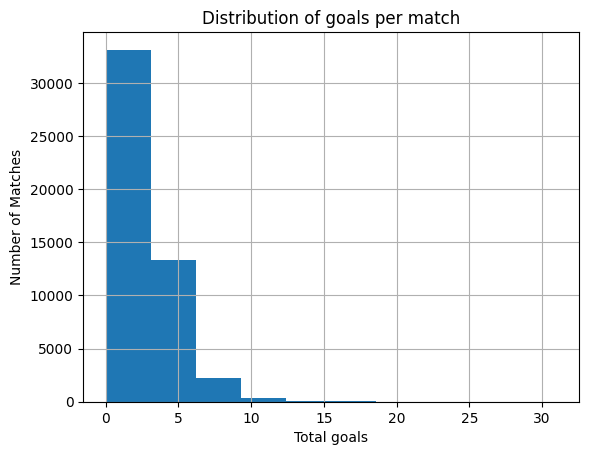

In [11]:
import matplotlib.pyplot as plt

matches_copy['total_goals'].hist(bins=10)

plt.xlabel("Total goals")
plt.ylabel("Number of Matches")
plt.title("Distribution of goals per match")


plt.show()